## Comparing the CFLIB original FITS plot and Interpolator plot 

#### For HD000249

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
from astropy.io import fits 

%matplotlib inline

In [2]:
path249 = "../FITS_data/249.fits"

In [3]:
with fits.open(path249) as data_249:
    hdr  = data_249[0].header

print(hdr)

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                15011 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel December 2001' / FITS file originator    DATE    = '2004-02-10T22:35:52' / Date FITS file was generated                  IRAF-TLM= '22:35:52 (10/02/2004)' / Time of last modification                   OBJECT  = '249     '           / Name of the object observed                    OBSERVAT= 'KPNO              '  /  observatory                                  TELESCOP= 'kpcdf             '  /  telescope name                               DETECTOR= 'f3kb              '  /  detector name                                APERTURE= '200 microns       '  /  apert

In [4]:
for i in hdr:
    if "catalogue" in i.lower():
        print(i)

print(hdr["OBJNAME"])    # name of the object with its catalogue

HD 249


3465.0


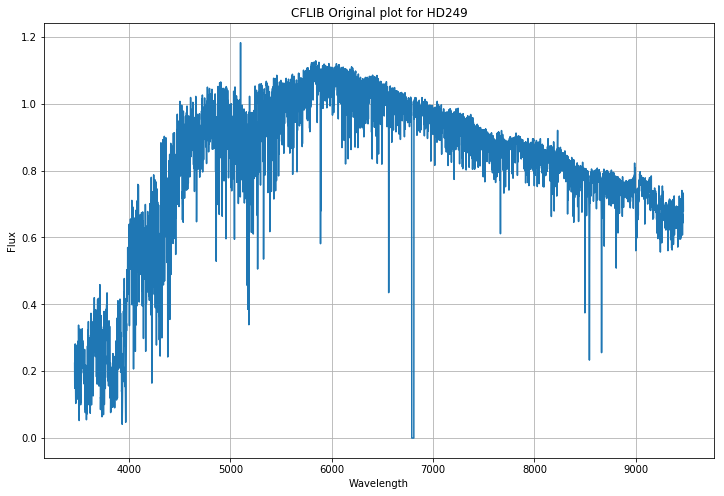

In [5]:
with fits.open(path249) as data_249:
    hdr = data_249[0].header
    
    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wave_points = len(data_249[0].data)

    wavelength = crval + cdelt * np.arange(n_wave_points)

    print(crval)

    flux = data_249[0].data

    plt.figure(figsize= (12, 8))
    plt.grid()
    plt.title("CFLIB Original plot for HD249")
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
    plt.plot(wavelength,flux)
    plt.show()



Plotting the Random Forest Interpolator flux wavelength continuum : 

In [6]:
df = pd.read_csv("asu (2).tsv", delimiter = "\t", encoding = "latin1")

Getting the atmospheric parameters for the HD000249 star

In [7]:
df[df["Name"] == b'HD000249  ']

,n_Name,Name,SpType,Teff,e_Teff,log(g),e_log(g),[Fe/H],e_[Fe/H],r_[Fe/H],SimbadName,_RA,_DE
2,,HD000249,K1IV,4757,28,2.88,0.09,-0.29,0.06,0,HD000249,001.84401,+26.45060


### Using the Interpolator: 

In [8]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [9]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7

In [10]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

Putting the parameters for the HD249 star in the interpolator

In [11]:
pred = InterpolateSpectrum(4757,2.88,-0.29)

Comparing the Interpolator continuum curve and original CFLIB curve for the HD000249 star : 

7339.5
9686


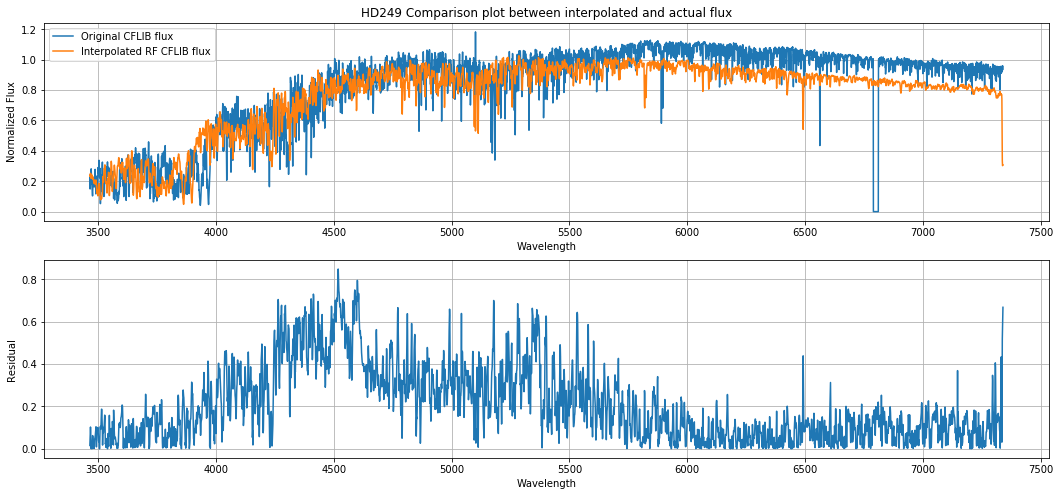

In [40]:
with fits.open(path249) as data_249:
    hdr = data_249[0].header
    
    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wave_points = len(data_249[0].data)          # total number of wavelength pixels

    flux = data_249[0].data                     # Flux array for the fits cflib data
    
    wavelength = crval + cdelt * np.arange(n_wave_points)         # setting up the wavelength axis for the CFLIB original

    int_wavelength = crval + 0.9 * np.arange(n_wave_points)[:4306]  # wavelength axis for Interpolated CFLIB

    # Looking for the last value of the interpolated flux to equalize the wavelength coverage of interpolated flux and original flux
    print(int_wavelength[-1])
    # Looking for the index of the wavelength nearest to the last wavelength of the interpolated flux
    for i in range(len(wavelength)):
        if 7339 < wavelength[i] < 7339.8:
            print(i)


    fig, axes = plt.subplots(2, 1, figsize = (18, 8))
    
    axes[0].plot(wavelength[:9686], flux[:9686], label = "Original CFLIB flux")
    axes[0].plot(int_wavelength, pred[0,:], label = "Interpolated RF CFLIB flux")
    axes[0].set_title("HD249 Comparison plot between interpolated and actual flux")
    axes[0].set_xlabel("Wavelength")
    axes[0].set_ylabel("Normalized Flux")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(int_wavelength, np.abs(flux[:4306] - pred[0,:]))
    axes[1].set_xlabel("Wavelength")
    axes[1].set_ylabel("Residual")
    axes[1].grid(True)

    plt.show()



    
    

Now checking for flux at 5550 A : 


Checking for normalization of fluxes :

In [43]:
for i in range(len(wavelength[:9686])):
    if wavelength[i] == 5550.200000000001:
        print(i)

5213


In [48]:
flux[5213]

1.058181

In [45]:
for i in range(len(int_wavelength)):
    if int_wavelength[i]//1 == 5550:
        print(int_wavelength[i]) 

5550.3


In [47]:
for i in range(len(int_wavelength)):
    if int_wavelength[i] == 5550.3:
        print(i)

2317


In [53]:
pred[0,:][2317]

0.9653294162710303

Checking for the flux value of approx 1 in interpolated flux array

In [ ]:
# Finding the index at which the flux value in the interpolated flux array is 1
for i in range(len(pred[0,:])):
    if pred[0,:][i] == 1:
        print(i)

2238


In [66]:
print("Interpolated flux is normalized at : {} A".format(int_wavelength[2238]))

Interpolated flux is normalized at : 5479.2 A
